In [ ]:
# pip install libraries
!pip install scikit-posthocs
!pip install timm

In [ ]:
#Import libraries
import os
import pandas as pd
import numpy as np
from glob import glob
import re
from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt
import cv2
from PIL import Image
from torch.utils.data import Dataset
from torch.utils.data import random_split, DataLoader
from torchvision import transforms
from torch.utils.data import random_split, DataLoader, ConcatDataset
import torch
import torch.nn as nn
import torchvision.models as models
import timm
import torch.optim as optim
from torch.optim.lr_scheduler import ReduceLROnPlateau
from collections import Counter
import torch.nn.functional as F
import random
from sklearn.metrics import confusion_matrix, classification_report
from tqdm import tqdm
import scikit_posthocs as sp
import math

In [ ]:
#Creatin groind truth binary lables
# CONFIG
root_dir = "/content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/train_E_SEF_LDA"
output_root = "/content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/train_E_SEF_LDA_BINARY"
os.makedirs(output_root, exist_ok=True)

# Define which folders are non-cracking (label 0)
no_cracking_prefixes = ["11"]

for folder in sorted(os.listdir(root_dir)):
    folder_path = os.path.join(root_dir, folder)
    if not os.path.isdir(folder_path):
        continue

    # Binary label rule
    if any(folder.startswith(prefix) for prefix in no_cracking_prefixes):
        folder_binary_label = 0
    else:
        folder_binary_label = 1

    # Create output sub-folder
    output_folder = os.path.join(output_root, folder)
    os.makedirs(output_folder, exist_ok=True)

    # Process each week's CSV
    for week_file in ["week-2.csv", "week-3.csv", "week-4.csv"]:
        csv_path = os.path.join(folder_path, week_file)
        if not os.path.exists(csv_path):
            continue

        df = pd.read_csv(csv_path)

        # Apply binary label directly
        if "Label" in df.columns:
            df.loc[0, "Label"] = folder_binary_label

        df.to_csv(os.path.join(output_folder, week_file), index=False)

print("Binary label conversion fully completed.")


Binary label conversion fully completed.


In [ ]:
#Data Loader
class CLAHEandEDGE:
    def __init__(self, clip_limit=3.0, grid_size=(8, 8)):
        self.clahe = cv2.createCLAHE(clipLimit=clip_limit, tileGridSize=grid_size)

    def __call__(self, pil_img):
        img = np.array(pil_img.convert("L"))                      # Convert to grayscale
        clahe_img = self.clahe.apply(img)                         # Apply CLAHE
        blurred = cv2.GaussianBlur(clahe_img, (3, 3), 0)          # Gaussian blur
        laplacian = cv2.Laplacian(blurred, cv2.CV_8U, ksize=3)    # Laplacian edge
        laplacian = cv2.convertScaleAbs(laplacian)                # Convert to 8-bit
        laplacian = cv2.bitwise_not(laplacian)                    # Invert edges

        resized = cv2.resize(laplacian, (224, 224))               # Resize to 224x224
        normalized = resized.astype(np.float32) / 255.0           # Normalize to [0,1]
        normalized = (normalized - 0.5) / 0.5                      # Normalize to mean=0.5, std=0.5

        return torch.tensor(normalized).unsqueeze(0)              # Shape: (1, 224, 224)

class BinaryTripletDataset(Dataset):
    def __init__(self, folder_path, transform=None):
        self.folder_path = folder_path
        self.transform = transform or CLAHEandEDGE()
        self.sample_folders = [f for f in os.listdir(folder_path)
                               if os.path.isdir(os.path.join(folder_path, f))]

    def __len__(self):
        return len(self.sample_folders)

    def __getitem__(self, idx):
        folder_name = self.sample_folders[idx]
        folder_path = os.path.join(self.folder_path, folder_name)
        weeks = ["week-2.csv", "week-3.csv", "week-4.csv"]

        image_triplet = []
        meta_triplet = []
        label = None

        for i, week_file in enumerate(weeks):
            week_path = os.path.join(folder_path, week_file)
            if not os.path.exists(week_path):
                image_triplet.append(torch.zeros(1, 224, 224))
                meta_triplet.append(torch.zeros(3))
                continue

            df = pd.read_csv(week_path)
            if df.empty or "Image_Path" not in df.columns:
                image_triplet.append(torch.zeros(1, 224, 224))
                meta_triplet.append(torch.zeros(3))
                continue

            try:
                img_path = df.iloc[0]["Image_Path"]
                image = Image.open(img_path).convert("L")  # Grayscale
                img_tensor = self.transform(image)  # Already preprocessed tensor
                image_triplet.append(img_tensor.clone().detach())

                # Extract metadata
                meta = df.drop(columns=["Image_Path", "Image_ID", "Label", "Irrigation"], errors="ignore")
                week_index = float(df["Week"].values[0][-1]) if "Week" in df.columns else (i + 2)
                meta["Week_Index"] = week_index
                meta_numeric = pd.to_numeric(meta.iloc[0], errors="coerce").fillna(0).values.astype("float32")
                meta_tensor = torch.tensor(meta_numeric[:3], dtype=torch.float32).clone().detach()
                meta_triplet.append(meta_tensor)

                if week_file == "week-4.csv" and "Label" in df.columns:
                    label = int(df.iloc[0]["Label"])

            except Exception as e:
                print(f"Error processing {week_path}: {e}")
                image_triplet.append(torch.zeros(1, 224, 224))
                meta_triplet.append(torch.zeros(3))

        stacked_images = torch.stack(image_triplet)      # (3, 1, 224, 224)
        stacked_metadata = torch.stack(meta_triplet)     # (3, 3)
        if label is None:
            label = -1

        return stacked_images, stacked_metadata, torch.tensor(label, dtype=torch.long)


In [ ]:
#Load north side data
# Image transforms - Removed ToTensor and Normalize here
image_transforms = CLAHEandEDGE()

# Directories
train_row3_dir = "/content/drive/MyDrive/Thesis/POM-IMG/train_row3_SEF_LDA_BINARY"
test_row3_dir = "/content/drive/MyDrive/Thesis/POM-IMG/test_row3_SEF_LDA_BINARY"

# Datasets
# Using BinaryTripletDataset now
full_train_dataset3 = BinaryTripletDataset(train_row3_dir, transform=image_transforms) # Pass the transform instance
test_row3_dataset = BinaryTripletDataset(test_row3_dir, transform=image_transforms) # Pass the transform instance

# Split train into 80% train / 20% val
train_size = int(0.8 * len(full_train_dataset3))
val_size = len(full_train_dataset3) - train_size
train_row3_dataset, val_row3_dataset = random_split(full_train_dataset3, [train_size, val_size])

# Loaders
train_loader3 = DataLoader(train_row3_dataset, batch_size=16, shuffle=True)
val_loader3 = DataLoader(val_row3_dataset, batch_size=16, shuffle=True)
test_loader3 = DataLoader(test_row3_dataset, batch_size=16, shuffle=False)

print("Row 3 loaders ready!")
print(f"Train samples: {len(train_row3_dataset)} | Val samples: {len(val_row3_dataset)} | Test samples: {len(test_row3_dataset)}")
print(f"Train size: {len(train_row3_dataset)} | Batch size: {train_loader3.batch_size}")
print(f"Number of batches: {len(train_loader3)}")

Row 3 loaders ready!
Train samples: 980 | Val samples: 245 | Test samples: 321
Train size: 980 | Batch size: 16
Number of batches: 62


In [ ]:
#Load south side data
# Image transforms - Removed ToTensor and Normalize here
image_transforms = CLAHEandEDGE()

# Directories
train_row4_dir = "/content/drive/MyDrive/Thesis/POM-IMG/train_row4_SEF_LDA_BINARY"
test_row4_dir = "/content/drive/MyDrive/Thesis/POM-IMG/test_row4_SEF_LDA_BINARY"

# Datasets
# Using BinaryTripletDataset now
full_train_dataset4 = BinaryTripletDataset(train_row4_dir, transform=image_transforms) # Pass the transform instance
test_row4_dataset = BinaryTripletDataset(test_row4_dir, transform=image_transforms) # Pass the transform instance

# Split train into 80% train / 20% val
train_size = int(0.8 * len(full_train_dataset4))
val_size = len(full_train_dataset4) - train_size
train_row4_dataset, val_row4_dataset = random_split(full_train_dataset4, [train_size, val_size])

# Loaders
train_loader4 = DataLoader(train_row4_dataset, batch_size=16, shuffle=True)
val_loader4 = DataLoader(val_row4_dataset, batch_size=16, shuffle=False)
test_loader4 = DataLoader(test_row4_dataset, batch_size=16, shuffle=False)

print("Row 4 loaders ready!")
print(f"Train samples: {len(train_row4_dataset)} | Val samples: {len(val_row4_dataset)} | Test samples: {len(test_row4_dataset)}")
print(f"Train size: {len(train_row4_dataset)} | Batch size: {train_loader4.batch_size}")
print(f"Number of batches: {len(train_loader4)}")

Row 4 loaders ready!
Train samples: 980 | Val samples: 245 | Test samples: 321
Train size: 980 | Batch size: 16
Number of batches: 62


In [ ]:
#Load combined noeth and south data
# Image transforms - Removed ToTensor and Normalize here
image_transforms = CLAHEandEDGE()

# Directories
train_row3_dir = "/content/drive/MyDrive/Thesis/POM-IMG/train_row3_SEF_LDA_BINARY"
train_row4_dir = "/content/drive/MyDrive/Thesis/POM-IMG/train_row4_SEF_LDA_BINARY"
test_row3_dir  = "/content/drive/MyDrive/Thesis/POM-IMG/test_row3_SEF_LDA_BINARY"
test_row4_dir  = "/content/drive/MyDrive/Thesis/POM-IMG/test_row4_SEF_LDA_BINARY"

# Datasets
# Using BinaryTripletDataset now
train_dataset3 = BinaryTripletDataset(train_row3_dir, transform=image_transforms) # Pass the transform instance
train_dataset4 = BinaryTripletDataset(train_row4_dir, transform=image_transforms) # Pass the transform instance
test_dataset3  = BinaryTripletDataset(test_row3_dir,  transform=image_transforms) # Pass the transform instance
test_dataset4  = BinaryTripletDataset(test_row4_dir,  transform=image_transforms) # Pass the transform instance

# Combine
combined_train_dataset = ConcatDataset([train_dataset3, train_dataset4])
combined_test_dataset  = ConcatDataset([test_dataset3, test_dataset4])

# Split train into 80% train / 20% val
train_size = int(0.8 * len(combined_train_dataset))
val_size = len(combined_train_dataset) - train_size
train_dataset5, val_dataset5 = random_split(combined_train_dataset, [train_size, val_size])

# DataLoaders
train_loader5 = DataLoader(train_dataset5, batch_size=32, shuffle=True)
val_loader5   = DataLoader(val_dataset5, batch_size=32, shuffle=True)
test_loader5  = DataLoader(combined_test_dataset, batch_size=32, shuffle=False)

print("Combined Row 3 + Row 4 DataLoaders ready!")
print(f"Train samples: {len(train_dataset5)} | Val samples: {len(val_dataset5)} | Test samples: {len(combined_test_dataset)}")

Combined Row 3 + Row 4 DataLoaders ready!
Train samples: 1960 | Val samples: 490 | Test samples: 642


In [ ]:
#Load combine north and south side data
# Image transforms
image_transforms =  CLAHEandEDGE()

# Directories 2024
train_row3_dir = "/content/drive/MyDrive/Thesis/POM-IMG/train_row3_SEF_LDA_BINARY"
train_row4_dir = "/content/drive/MyDrive/Thesis/POM-IMG/train_row4_SEF_LDA_BINARY"
test_row3_dir  = "/content/drive/MyDrive/Thesis/POM-IMG/test_row3_SEF_LDA_BINARY"
test_row4_dir  = "/content/drive/MyDrive/Thesis/POM-IMG/test_row4_SEF_LDA_BINARY"
# Directories 2025
train_W_dir = "/content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/train_W_SEF_LDA_BINARY"
train_E_dir = "/content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/train_E_SEF_LDA_BINARY"
test_W_dir  = "/content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/test_W_SEF_LDA_BINARY"
test_E_dir  = "/content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/test_E_SEF_LDA_BINARY"

# Datasets 2024
train_dataset3 = BinaryTripletDataset(train_row3_dir, transform=image_transforms)
train_dataset4 = BinaryTripletDataset(train_row4_dir, transform=image_transforms)
test_dataset3  = BinaryTripletDataset(test_row3_dir,  transform=image_transforms)
test_dataset4  = BinaryTripletDataset(test_row4_dir,  transform=image_transforms)

# Datasets 2025
train_datasetW = BinaryTripletDataset(train_W_dir, transform=image_transforms)
train_datasetE = BinaryTripletDataset(train_E_dir, transform=image_transforms)
test_datasetW  = BinaryTripletDataset(test_W_dir,  transform=image_transforms)
test_datasetE  = BinaryTripletDataset(test_E_dir,  transform=image_transforms)


# Combine 2024,2024
combined_train_dataset = ConcatDataset([train_dataset3, train_dataset4, test_dataset3, test_dataset4])
combined_test_dataset  = ConcatDataset([train_datasetW, train_datasetE, test_datasetW, test_datasetE])

# Split train into 80% train / 20% val
train_size = int(0.8 * len(combined_train_dataset))
val_size = len(combined_train_dataset) - train_size
train_dataset6, val_dataset6 = random_split(combined_train_dataset, [train_size, val_size])

# DataLoaders
train_loader6 = DataLoader(train_dataset6, batch_size=32, shuffle=True)
val_loader6   = DataLoader(val_dataset6, batch_size=32, shuffle=True)
test_loader6  = DataLoader(combined_test_dataset, batch_size=32, shuffle=False)

print("Combined Row 3 + Row 4 DataLoaders ready!")
print(f"Train samples: {len(train_dataset6)} | Val samples: {len(val_dataset6)} | Test samples: {len(combined_test_dataset)}")


Combined Row 3 + Row 4 DataLoaders ready!
Train samples: 2473 | Val samples: 619 | Test samples: 1008


In [ ]:
# LSTM Attention Block
class AttentionBlock(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.attn = nn.Linear(hidden_dim, 1)

    def forward(self, lstm_out):
        # lstm_out: (B, T, H)
        attn_weights = self.attn(lstm_out)         # (B, T, 1)
        attn_weights = torch.softmax(attn_weights, dim=1)  # Normalize across time
        context = (lstm_out * attn_weights).sum(dim=1)     # Weighted sum: (B, H)
        return context

In [ ]:
# CNN Attention Block
class TemporalImageAttention(nn.Module):
    def __init__(self, feature_dim, hidden_dim=128):
        super().__init__()
        self.attn_mlp = nn.Sequential(
            nn.Linear(feature_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1)
        )

    def forward(self, x):
        # x: (B, T, D) where T = 3 time steps (weeks), D = CNN feature dim (2048)
        scores = self.attn_mlp(x)                      # (B, T, 1)
        weights = torch.softmax(scores, dim=1)         # (B, T, 1)
        context = (x * weights).sum(dim=1)             # (B, D)
        return context

In [ ]:
# PomRowModel with timm ConvNeXt
class PomRowModel(nn.Module):
    def __init__(self, num_metadata_features, hidden_dim=128, lstm_layers=3, num_classes=2):
        super().__init__()

        # ConvNeXt from timm
        self.cnn = timm.create_model('convnext_base', pretrained=True, num_classes=0)  # No FC layer
        cnn_output_dim = self.cnn.num_features  # Should be 1024 for convnext_base

        # Modify the first convolutional layer to accept 1 channel
        self.cnn.stem[0] = nn.Conv2d(1, 128, kernel_size=(4, 4), stride=(4, 4))

        # LSTM for Metadata
        self.lstm = nn.LSTM(input_size=num_metadata_features,
                            hidden_size=hidden_dim,
                            num_layers=lstm_layers,
                            batch_first=True)

        # Dual Attention
        self.meta_attention = AttentionBlock(hidden_dim)
        self.img_attention = TemporalImageAttention(cnn_output_dim)

        # Fully Connected Head
        self.fc = nn.Sequential(
            nn.Linear(cnn_output_dim + hidden_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(256, num_classes)
        )

    def forward(self, imgs, meta):
        # imgs: (B, T, C, H, W), meta: (B, 3, D)
        # Assuming C is 1 here based on the model modification
        B, T, C, H, W = imgs.shape
        # Reshape and add channel dimension if it's missing (assuming input is B, T, H, W or B, T, 1, H, W)
        imgs = imgs.view(B * T, C, H, W)  # (B*T, C, H, W)
        # If the input was (B, T, H, W), C would be H after view, so we need to handle that
        if C != 1: # This check might be too simplistic, better to ensure input is (B, T, 1, H, W) from DataLoader
             # Assuming the input is (B, T, H, W) and needs a channel dimension added
             imgs = imgs.view(B * T, 1, H, W) # Explicitly add channel dimension if it was missing

        cnn_feats = self.cnn(imgs)        # (B*T, F)
        cnn_feats = cnn_feats.view(B, T, -1)  # (B, 3, F)
        img_attn = self.img_attention(cnn_feats)  # (B, F)

        lstm_out, _ = self.lstm(meta)          # (B, 3, H)
        meta_attn = self.meta_attention(lstm_out)  # (B, H)

        combined = torch.cat([img_attn, meta_attn], dim=1)  # (B, F + H)
        return self.fc(combined)

In [ ]:
#Traning Loop
GPU = 0
SEED = 2023

torch.manual_seed(SEED)
torch.cuda.manual_seed(SEED)
np.random.seed(SEED)
random.seed(SEED)
torch.backends.cudnn.benchmark = False
torch.backends.cudnn.deterministic = True
os.environ['PYTHONHASHSEED'] = str(SEED)
torch.cuda.manual_seed_all(SEED)

device = torch.device(f"cuda:{GPU}" if torch.cuda.is_available() else "cpu")

class FocalLoss(nn.Module):
    def __init__(self, alpha=1.0, gamma=2.0, weight=None):
        super().__init__()
        self.alpha = alpha
        self.gamma = gamma
        self.weight = weight  # Class weights (optional)

    def forward(self, logits, targets):
        ce_loss = F.cross_entropy(logits, targets, weight=self.weight, reduction='none')  # (B,)
        probs = F.softmax(logits, dim=1)  # (B, C)
        # Ensure targets_one_hot has the correct number of classes
        targets_one_hot = F.one_hot(targets, num_classes=logits.size(1)).float()  # (B, C)
        pt = (probs * targets_one_hot).sum(dim=1)  # (B,)
        focal_weight = self.alpha * (1 - pt) ** self.gamma  # (B,)
        loss = focal_weight * ce_loss  # (B,)
        return loss.mean()

def compute_class_weights(dataloader, num_classes, device):
    all_labels = []
    for _, _, labels in dataloader:
        # Filter out labels that are -1 (if you used -1 for missing labels)
        valid_labels = [label.item() for label in labels if label.item() != -1]
        all_labels.extend(valid_labels)


    label_counts = Counter(all_labels)
    total = sum(label_counts.values())
    weights = []

    for i in range(num_classes):
        # Handle cases where a class might be missing in the dataset split
        class_count = label_counts.get(i, 1)  # Use 1 instead of 0 to avoid division by zero
        weight = total / (num_classes * class_count)
        weights.append(weight)

    # Normalize weights (optional)
    weights = np.array(weights)
    weights = weights / np.mean(weights)

    return torch.tensor(weights, dtype=torch.float32).to(device)


def validate(model, val_loader, criterion, device):
    model.eval()
    val_loss = 0

    with torch.no_grad():
        for images, metadata, labels in val_loader:
            # Filter out samples with missing labels if you used -1
            valid_indices = [i for i, label in enumerate(labels) if label.item() != -1]
            if not valid_indices:
                continue
            images = images[valid_indices].to(device)
            metadata = metadata[valid_indices].to(device)
            labels = labels[valid_indices].to(device)


            outputs = model(images, metadata)
            loss = criterion(outputs, labels)
            val_loss += loss.item()

    return val_loss / len(val_loader)


def train_model(model, dataloader, val_loader, num_epochs=10, lr=0.0003, num_classes=2): # Changed num_classes to 2
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)

    class_weights = compute_class_weights(dataloader, num_classes, device)
    print(f" Normalized Class Weights: {class_weights.tolist()}")

    criterion = FocalLoss(alpha=1.0, gamma=2.0, weight=class_weights)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    scheduler = ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=2)

    best_val_loss = float('inf')
    best_model_weights = None

    for epoch in range(num_epochs):
        model.train()
        total_loss = 0
        print(f"\n Epoch {epoch+1}/{num_epochs}")

        for i, (images, metadata, labels) in enumerate(dataloader):
            # Filter out samples with missing labels if you used -1
            valid_indices = [i for i, label in enumerate(labels) if label.item() != -1]
            if not valid_indices:
                continue
            images = images[valid_indices].to(device)
            metadata = metadata[valid_indices].to(device)
            labels = labels[valid_indices].to(device)

            # initial_weights = model.cnn.stem[0].weight.clone().detach() # Commented out to avoid unused variable warning

            optimizer.zero_grad()
            outputs = model(images, metadata)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            # updated_weights = model.cnn.stem[0].weight # Commented out to avoid unused variable warning

            total_loss += loss.item()

        avg_train_loss = total_loss / len(dataloader)
        print(f" Epoch {epoch+1} Avg Train Loss: {avg_train_loss:.4f}")

        val_loss = validate(model, val_loader, criterion, device)
        print(f" Validation Loss: {val_loss:.4f}")
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_model_weights = model.state_dict()
            print(f" New best model saved (val_loss = {val_loss:.4f})")

    # Load best weights before returning
    if best_model_weights is not None:
        model.load_state_dict(best_model_weights)
        print(" Loaded best model weights from memory!")

    print(" Training complete!")
    return model

In [ ]:
# Train Model
# Set number of metadata features
num_metadata_features = 3

# Initialize model
model = PomRowModel(num_metadata_features=num_metadata_features)

# Train the model
train_model(model, train_loader6, val_loader6, num_epochs=30, lr=0.001)

 Normalized Class Weights: [1.3408814668655396, 0.6591184735298157]

 Epoch 1/30
 Epoch 1 Avg Train Loss: 0.1538
 Validation Loss: 0.1370
 New best model saved (val_loss = 0.1370)

 Epoch 2/30
 Epoch 2 Avg Train Loss: 0.1366
 Validation Loss: 0.1352
 New best model saved (val_loss = 0.1352)

 Epoch 3/30
 Epoch 3 Avg Train Loss: 0.1321
 Validation Loss: 0.1326
 New best model saved (val_loss = 0.1326)

 Epoch 4/30
 Epoch 4 Avg Train Loss: 0.1315
 Validation Loss: 0.1290
 New best model saved (val_loss = 0.1290)

 Epoch 5/30
 Epoch 5 Avg Train Loss: 0.1273
 Validation Loss: 0.1270
 New best model saved (val_loss = 0.1270)

 Epoch 6/30
 Epoch 6 Avg Train Loss: 0.1241
 Validation Loss: 0.1244
 New best model saved (val_loss = 0.1244)

 Epoch 7/30
 Epoch 7 Avg Train Loss: 0.1212
 Validation Loss: 0.1259

 Epoch 8/30
 Epoch 8 Avg Train Loss: 0.1214
 Validation Loss: 0.1227
 New best model saved (val_loss = 0.1227)

 Epoch 9/30
 Epoch 9 Avg Train Loss: 0.1190
 Validation Loss: 0.1176
 New bes

PomRowModel(
  (cnn): ConvNeXt(
    (stem): Sequential(
      (0): Conv2d(1, 128, kernel_size=(4, 4), stride=(4, 4))
      (1): LayerNorm2d((128,), eps=1e-06, elementwise_affine=True)
    )
    (stages): Sequential(
      (0): ConvNeXtStage(
        (downsample): Identity()
        (blocks): Sequential(
          (0): ConvNeXtBlock(
            (conv_dw): Conv2d(128, 128, kernel_size=(7, 7), stride=(1, 1), padding=(3, 3), groups=128)
            (norm): LayerNorm((128,), eps=1e-06, elementwise_affine=True)
            (mlp): Mlp(
              (fc1): Linear(in_features=128, out_features=512, bias=True)
              (act): GELU()
              (drop1): Dropout(p=0.0, inplace=False)
              (norm): Identity()
              (fc2): Linear(in_features=512, out_features=128, bias=True)
              (drop2): Dropout(p=0.0, inplace=False)
            )
            (shortcut): Identity()
            (drop_path): Identity()
          )
          (1): ConvNeXtBlock(
            (conv_dw):

In [ ]:
#Evaluation loop
def test_model(model, test_loader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            image_seq, metadata_seq, labels = batch

            image_seq = image_seq.to(device)       # shape: (B, 3, C, H, W)
            metadata_seq = metadata_seq.to(device) # shape: (B, 3, D)
            labels = labels.to(device)             # shape: (B,)

            outputs = model(image_seq, metadata_seq)  # shape: (B, num_classes)
            _, preds = torch.max(outputs, 1)       # Get predicted class indices

            # Extend lists directly with tensors, converting to NumPy later
            all_preds.extend(preds.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())

    # Convert to numpy arrays after the loop
    all_preds = np.array(all_preds)
    all_labels = np.array(all_labels)

    # Accuracy
    accuracy = 100 * np.sum(all_preds == all_labels) / len(all_labels)
    print(f" Test Accuracy: {accuracy:.2f}%")

    # Confusion matrix
    cm = confusion_matrix(all_labels, all_preds)
    print("\n Confusion Matrix:")
    print(cm)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Confusion Matrix")
    plt.show()

    # Classification report
    print("\n Classification Report:")
    print(classification_report(all_labels, all_preds, digits=3))

    return all_preds, all_labels

 Test Accuracy: 64.98%

 Confusion Matrix:
[[  0  64]
 [289 655]]


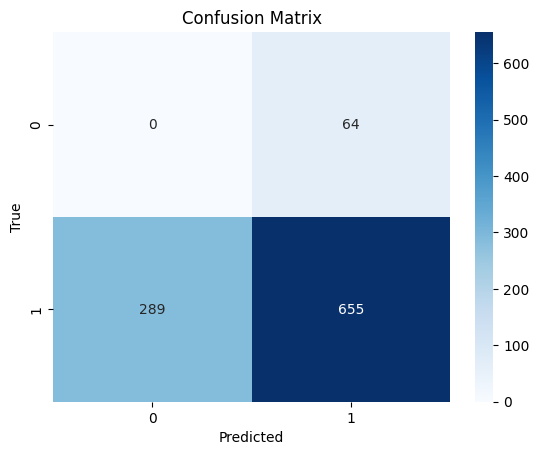


 Classification Report:
              precision    recall  f1-score   support

           0      0.000     0.000     0.000        64
           1      0.911     0.694     0.788       944

    accuracy                          0.650      1008
   macro avg      0.455     0.347     0.394      1008
weighted avg      0.853     0.650     0.738      1008



In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# test_loader should yield: (image_seq, metadata_seq, labels)
preds, labels = test_model(model, test_loader6, device)

In [ ]:
# Save the trained model
model_save_path = "/content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/2025_LSTM_convnext_LADS_32B_BINARY_LR0001_CL3_GRID8_G3_EDGE3.pth"
torch.save(model.state_dict(), model_save_path)
print(f" Model saved to {model_save_path}")

 Model saved to /content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/2025_LSTM_convnext_LADS_32B_BINARY_LR0001_CL3_GRID8_G3_EDGE3.pth


In [ ]:
#AA metric comprison data
# Load models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

row3_model = PomRowModel(num_metadata_features=3).to(device)
row4_model = PomRowModel(num_metadata_features=3).to(device)

row3_model.load_state_dict(torch.load("/content/drive/MyDrive/Thesis/POM-IMG/BINARY_com5_convnext_atten_LADF_16batch_30epochs_LR0.001_Gray_CLAHE_CL2_GRID16_Blur5_EDGE5_LAPLACIAN/LSTM_convnext_LADS_32B_BINARY_LR00001_CL2_GRID16_G5_EDGE5.pth", map_location=device))
row4_model.load_state_dict(torch.load("/content/drive/MyDrive/Thesis/POM-IMG/BINARY_com5_convnext_atten_LADF_16batch_30epochs_LR0.001_Gray_CLAHE_CL2_GRID16_Blur5_EDGE5_LAPLACIAN/LSTM_convnext_LADS_32B_BINARY_LR00001_CL2_GRID16_G5_EDGE5.pth", map_location=device))

row3_model.eval()
row4_model.eval()

# Set test folder path and load folder names
test_row3_dir = "/content/drive/MyDrive/Thesis/POM-IMG/train_row3_SEF_LDA_BINARY"
folder_names = sorted([
    f for f in os.listdir(test_row3_dir)
    if os.path.isdir(os.path.join(test_row3_dir, f))
])

# Run predictions and compare
agree_and_correct = 0
total_samples = 0
disagreements = []
all_preds = []

for batch_row3, batch_row4 in tqdm(zip(test_loader3, test_loader4), total=len(test_loader3)):
    images_r3, meta_r3, labels_r3 = batch_row3
    images_r4, meta_r4, labels_r4 = batch_row4

    images_r3 = images_r3.to(device)
    meta_r3 = meta_r3.to(device)
    images_r4 = images_r4.to(device)
    meta_r4 = meta_r4.to(device)
    labels = labels_r3.to(device)  # Assuming same labels for both

    with torch.no_grad():
        preds_r3 = row3_model(images_r3, meta_r3).argmax(dim=1)
        preds_r4 = row4_model(images_r4, meta_r4).argmax(dim=1)

    min_batch_size = min(len(preds_r3), len(preds_r4))

    for i in range(min_batch_size):
        pred3 = preds_r3[i].item()
        pred4 = preds_r4[i].item()
        label = labels[i].item()
        folder = folder_names[total_samples]  # Match folder name to sample

        if pred3 == pred4 and pred3 == label:
            agree_and_correct += 1
        elif pred3 != pred4:
            disagreements.append((folder, pred3, pred4, label))

        all_preds.append((folder, pred3, pred4, label))
        total_samples += 1

# Report results
accuracy = agree_and_correct / total_samples
print(f"\n Agreement Accuracy: {accuracy:.4f}")
print(f" Disagreements: {len(disagreements)} / {total_samples}")

# Save to CSV
results_df = pd.DataFrame(all_preds, columns=["Folder", "Row3_Pred", "Row4_Pred", "True_Label"])
results_df.to_csv("/content/drive/MyDrive/Thesis/POM-IMG/model_comparison_results.csv", index=False)
print("Saved: model_comparison_results.csv")

100%|██████████| 21/21 [00:18<00:00,  1.13it/s]


 Agreement Accuracy: 0.4455
 Disagreements: 71 / 321
Saved: model_comparison_results.csv


In [ ]:
#Load combine north and south side data
# Image transforms
image_transforms =  CLAHEandEDGE()

# Directories
train_W_dir = "/content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/train_W_SEF_LDA_BINARY"
test_W_dir  = "/content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/test_W_SEF_LDA_BINARY"


# Datasets
train_datasetW = BinaryTripletDataset(train_W_dir, transform=image_transforms)
test_datasetW = BinaryTripletDataset(test_W_dir,  transform=image_transforms)


# Combine
combined_W = ConcatDataset([train_datasetW, test_datasetW])

W_loader  = DataLoader(combined_W, batch_size=8, shuffle=False)

print("Combined Row 3 + Row 4 DataLoaders ready!")
print(f" samples: {len(combined_W)}")


Combined Row 3 + Row 4 DataLoaders ready!
 samples: 504


In [ ]:
#Load combine north and south side data
# Image transforms
image_transforms =  CLAHEandEDGE()

# Directories
train_E_dir = "/content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/train_E_SEF_LDA_BINARY"
test_E_dir  = "/content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/test_E_SEF_LDA_BINARY"


# Datasets
train_datasetE = BinaryTripletDataset(train_E_dir, transform=image_transforms)
test_datasetE = BinaryTripletDataset(test_E_dir,  transform=image_transforms)


# Combine
combined_E = ConcatDataset([train_datasetE, test_datasetE])

E_loader  = DataLoader(combined_E, batch_size=8, shuffle=False)

print("Combined Row 3 + Row 4 DataLoaders ready!")
print(f" samples: {len(combined_E)}")

Combined Row 3 + Row 4 DataLoaders ready!
 samples: 504


In [ ]:
# AA metric side of the field comparison
# Load models
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

row3_model = PomRowModel(num_metadata_features=3).to(device)
row4_model = PomRowModel(num_metadata_features=3).to(device)

row3_model.load_state_dict(torch.load("/content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/2025_BINARY_LSTM_convnext_LADS_32B_BINARY_LR0001_CL3_GRID8_G3_EDGE3/2025_LSTM_convnext_LADS_32B_BINARY_LR0001_CL3_GRID8_G3_EDGE3.pth", map_location=device))
row4_model.load_state_dict(torch.load("/content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/2025_BINARY_LSTM_convnext_LADS_32B_BINARY_LR0001_CL3_GRID8_G3_EDGE3/2025_LSTM_convnext_LADS_32B_BINARY_LR0001_CL3_GRID8_G3_EDGE3.pth", map_location=device))

row3_model.eval()
row4_model.eval()

# Paths to your two folders
row3_dir = "/content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/train_W_SEF_LDA_BINARY"
row4_dir = "/content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/test_W_SEF_LDA_BINARY"

# Get folder names from the datasets used by W_loader (assuming W and E loaders are aligned)
folder_names = []
for ds in W_loader.dataset.datasets:
    folder_names.extend(ds.sample_folders)

# Run predictions and compare
agree_and_correct = 0
total_samples = 0
disagreements = []
all_preds = []

# Correct the total for tqdm to reflect the actual number of batches
for batch_row3, batch_row4 in tqdm(zip(W_loader, E_loader), total=len(W_loader)):
    images_r3, meta_r3, labels_r3 = batch_row3
    images_r4, meta_r4, labels_r4 = batch_row4

    images_r3 = images_r3.to(device)
    meta_r3 = meta_r3.to(device)
    images_r4 = images_r4.to(device)
    meta_r4 = meta_r4.to(device)
    labels = labels_r3.to(device)  # Assuming same labels for both

    with torch.no_grad():
        preds_r3 = row3_model(images_r3, meta_r3).argmax(dim=1)
        preds_r4 = row4_model(images_r4, meta_r4).argmax(dim=1)

    min_batch_size = min(len(preds_r3), len(preds_r4))

    for i in range(min_batch_size):
        pred3 = preds_r3[i].item()
        pred4 = preds_r4[i].item()
        label = labels[i].item()
        folder = folder_names[total_samples]  # Match folder name to sample

        if pred3 == pred4 and pred3 == label:
            agree_and_correct += 1
        elif pred3 != pred4:
            disagreements.append((folder, pred3, pred4, label))

        all_preds.append((folder, pred3, pred4, label))
        total_samples += 1

# Report results
accuracy = agree_and_correct / total_samples
print(f"\n Agreement Accuracy: {accuracy:.4f}")
print(f" Disagreements: {len(disagreements)} / {total_samples}")

# Save to CSV
results_df = pd.DataFrame(all_preds, columns=["Folder", "W_Pred", "E_Pred", "True_Label"])
results_df.to_csv("/content/drive/MyDrive/Thesis/POM-IMG/0008_IL_TZR/model_comparison_results.csv", index=False)
print("Saved: model_comparison_results.csv")

100%|██████████| 63/63 [00:34<00:00,  1.83it/s]


 Agreement Accuracy: 0.3690
 Disagreements: 283 / 504
Saved: model_comparison_results.csv
